# 02 — Análise Exploratória de Dados (EDA)

Este notebook realiza a análise exploratória do dataset unificado.

**Objetivo:** Entender as distribuições das features, correlações entre variáveis e relação com a variável alvo.

**Pré-requisito:** Executar o notebook `01_coleta_e_limpeza.ipynb` primeiro.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.utils import load_processed_data, FIGURES_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

FEATURES = [
    'pop_total', 'pop_urbana_pct', 'perc_jovens_15_29',
    'renda_per_capita', 'taxa_desemprego', 'taxa_analfabetismo_15',
    'perc_esgoto_adequado', 'gini', 'idhm', 'idhm_renda',
    'idhm_longevidade', 'idhm_educacao', 'perc_pobres',
    'pib_per_capita', 'densidade_demografica',
]
TARGET = 'alta_violencia'

In [2]:
df = load_processed_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (5570, 18)


,cod_ibge,pop_total,pop_urbana_pct,perc_jovens_15_29,renda_per_capita,taxa_desemprego,taxa_analfabetismo_15,perc_esgoto_adequado,gini,idhm,idhm_renda,idhm_longevidade,idhm_educacao,perc_pobres,pib_per_capita,densidade_demografica,taxa_homicidios,alta_violencia
0,1100015,21494.0,60.3471,22.2108,1210.60,1.6919,9.33,0.4678,0.58,0.641,0.657,0.763,0.526,26.04,34170.791849,3.041406,9.304922,0
1,1100023,96833.0,86.6977,24.9894,1458.57,2.8638,6.25,1.9932,0.53,0.702,0.716,0.806,0.600,11.54,33163.219150,21.877513,12.392470,1
2,1100031,5351.0,53.1863,17.4173,1323.79,1.6309,10.62,1.5760,0.51,0.650,0.650,0.757,0.559,21.20,44555.036442,4.071208,37.376191,1
3,1100049,86887.0,82.7592,24.2637,1625.88,2.1154,5.93,67.1899,0.57,0.718,0.727,0.821,0.620,13.08,32139.514542,22.907197,8.056441,0
4,1100056,15890.0,88.8357,21.9509,1554.33,1.4391,7.49,57.9942,0.50,0.692,0.688,0.799,0.602,13.70,46762.869729,5.709057,18.879799,1


## 2.1 Visão geral do dataset

Dimensões, tipos de dados, valores ausentes.

In [3]:
print("=== Tipos e nulos ===")
df.info()
print("\n=== Estatísticas descritivas ===")
df[FEATURES + [TARGET]].describe().round(3)

=== Tipos e nulos ===
<class 'pandas.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cod_ibge               5570 non-null   int64  
 1   pop_total              5570 non-null   float64
 2   pop_urbana_pct         5570 non-null   float64
 3   perc_jovens_15_29      5570 non-null   float64
 4   renda_per_capita       5570 non-null   float64
 5   taxa_desemprego        5570 non-null   float64
 6   taxa_analfabetismo_15  5570 non-null   float64
 7   perc_esgoto_adequado   5570 non-null   float64
 8   gini                   5570 non-null   float64
 9   idhm                   5570 non-null   float64
 10  idhm_renda             5570 non-null   float64
 11  idhm_longevidade       5570 non-null   float64
 12  idhm_educacao          5570 non-null   float64
 13  perc_pobres            5570 non-null   float64
 14  pib_per_capita         5570 non-null   float6

,pop_total,pop_urbana_pct,perc_jovens_15_29,renda_per_capita,taxa_desemprego,taxa_analfabetismo_15,perc_esgoto_adequado,gini,idhm,idhm_renda,idhm_longevidade,idhm_educacao,perc_pobres,pib_per_capita,densidade_demografica,alta_violencia
count,5.570000e+03,5570.000,5570.000,5570.000,5570.000,5570.000,5570.000,5570.000,5570.000,5570.000,5570.000,5570.000,5570.000,5570.000,5570.000,5570.0
mean,3.645974e+04,69.039,21.567,1211.587,5.102,10.960,37.862,0.494,0.659,0.643,0.802,0.559,23.166,34443.666,115.972,0.5
std,2.065187e+05,20.137,2.795,493.338,4.065,7.004,32.909,0.066,0.072,0.080,0.045,0.093,17.871,39560.523,594.973,0.5
min,8.330000e+02,7.331,11.783,288.650,0.088,0.500,0.032,0.280,0.418,0.400,0.672,0.207,0.190,5697.281,0.154,0.0
25%,5.228000e+03,54.114,19.676,772.390,2.283,5.100,4.191,0.450,0.600,0.572,0.770,0.490,7.040,13608.179,11.336,0.0
50%,1.106500e+04,70.835,21.515,1182.540,4.134,8.940,32.552,0.490,0.665,0.654,0.808,0.560,18.100,24564.556,24.297,0.5
75%,2.442725e+04,86.051,23.384,1520.358,6.903,16.468,67.652,0.540,0.718,0.707,0.836,0.630,38.425,41549.294,53.626,1.0
max,1.145200e+07,100.000,37.393,4299.910,50.972,36.850,99.948,0.800,0.862,0.891,0.894,0.825,78.590,919482.368,13416.814,1.0


## 2.2 Distribuição da variável alvo

Verificar o balanceamento entre as classes (alta vs. baixa violência).

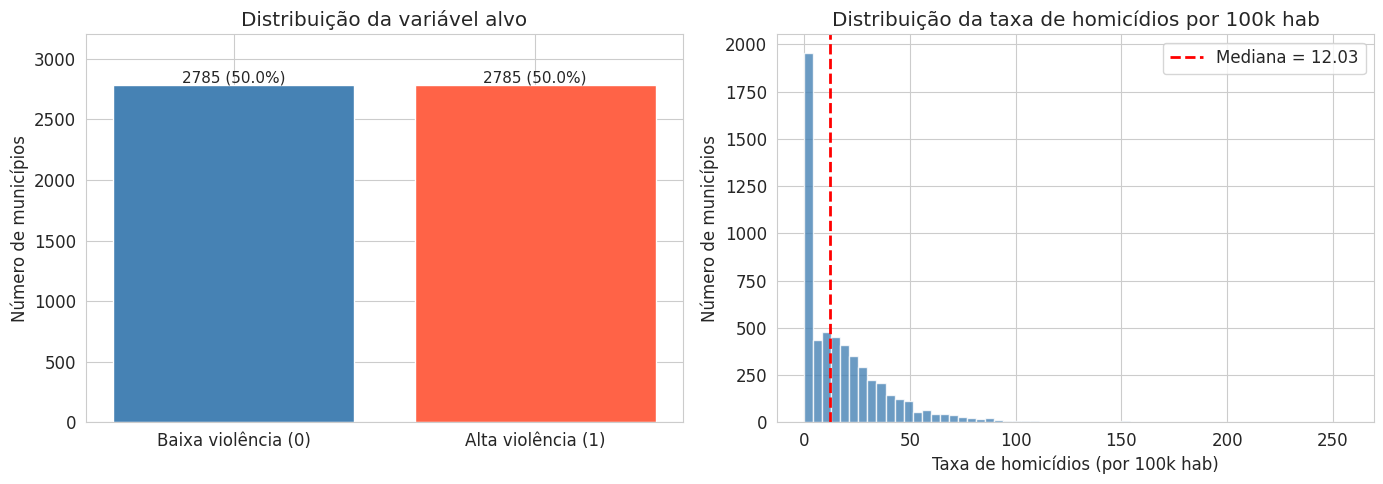


Mediana da taxa de homicídios (threshold): 12.03 por 100k hab
Municípios com alta violência:  2785 (50.0%)
Municípios com baixa violência: 2785 (50.0%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot das classes
counts = df[TARGET].value_counts().sort_index()
axes[0].bar(['Baixa violência (0)', 'Alta violência (1)'], counts.values, color=['steelblue', 'tomato'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Distribuição da variável alvo')
axes[0].set_ylabel('Número de municípios')
axes[0].set_ylim(0, counts.max() * 1.15)

# Histograma da taxa de homicídios com linha da mediana
mediana = df['taxa_homicidios'].median()
axes[1].hist(df['taxa_homicidios'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(mediana, color='red', linestyle='--', linewidth=2, label=f'Mediana = {mediana:.2f}')
axes[1].set_title('Distribuição da taxa de homicídios por 100k hab')
axes[1].set_xlabel('Taxa de homicídios (por 100k hab)')
axes[1].set_ylabel('Número de municípios')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_distribuicao_alvo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMediana da taxa de homicídios (threshold): {mediana:.2f} por 100k hab")
print(f"Municípios com alta violência:  {counts[1]} ({counts[1]/len(df)*100:.1f}%)")
print(f"Municípios com baixa violência: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")

## 2.3 Distribuição das features

Histogramas e boxplots de cada feature socioeconômica.

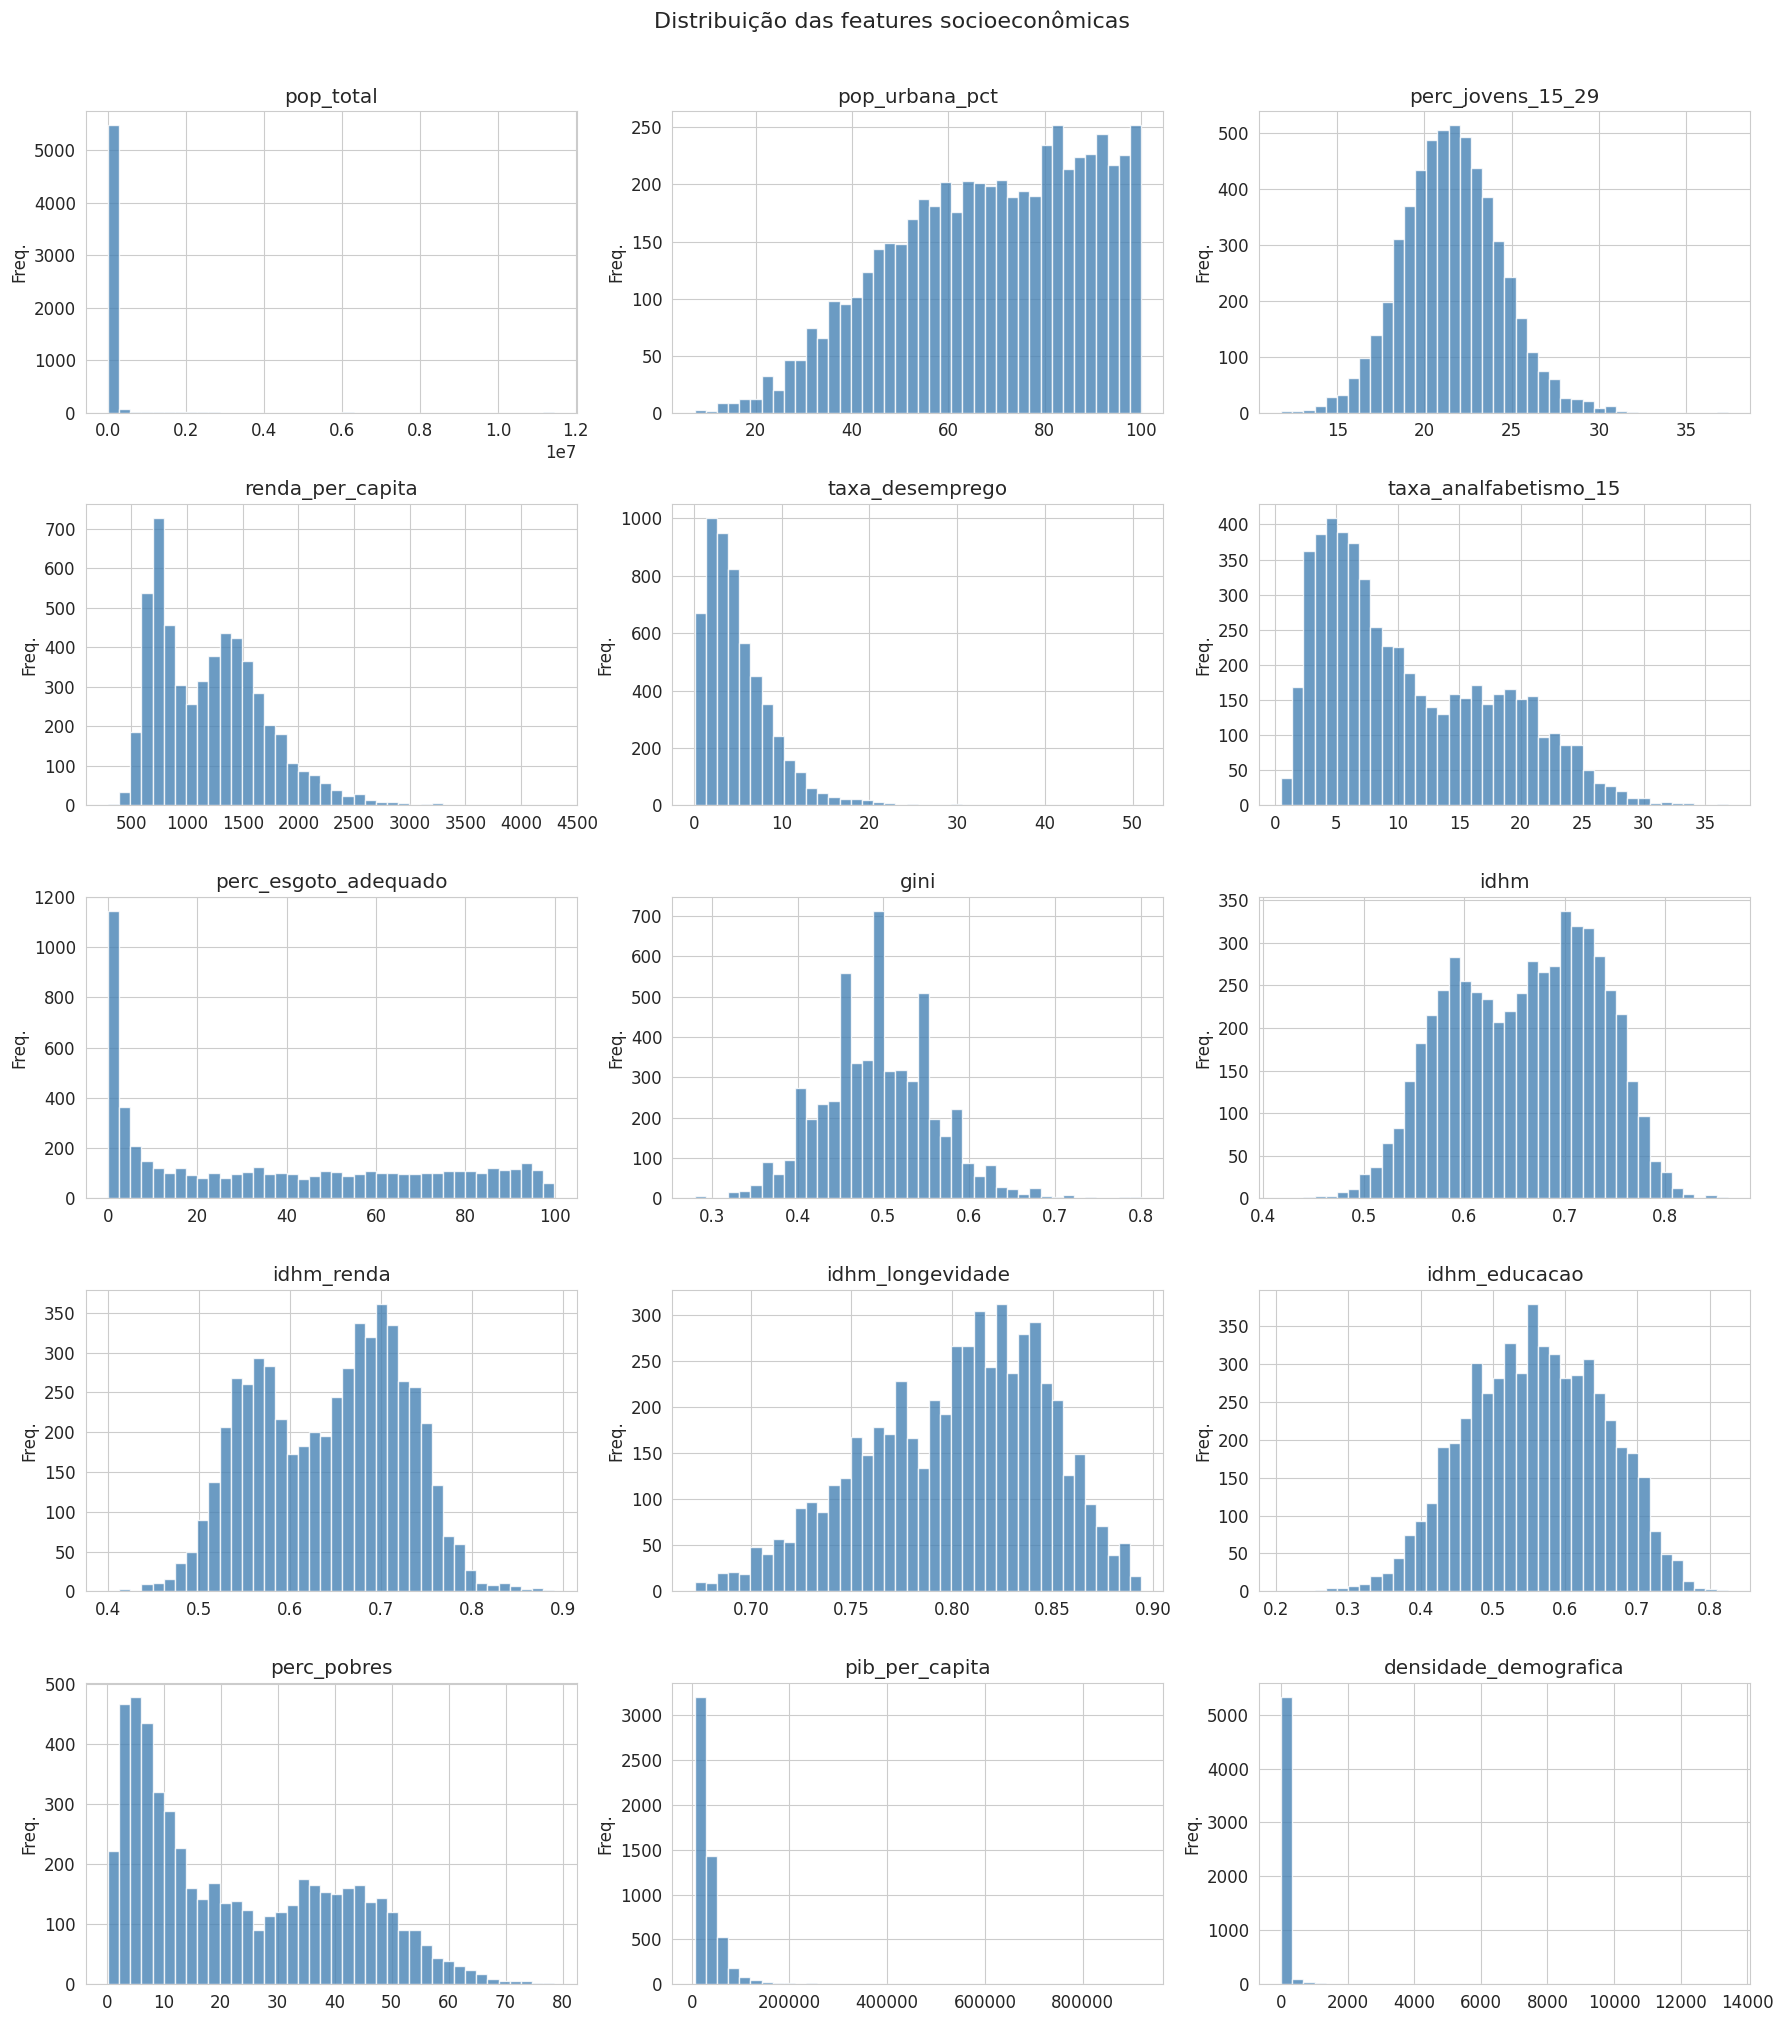

/tmp/ipykernel_120750/1325429359.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_120750/1325429359.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_120750/1325429359.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_120750/1325429359.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_120750/1325429359.py:30: MatplotlibDeprecationWarning

/tmp/ipykernel_120750/1325429359.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_120750/1325429359.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_120750/1325429359.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_120750/1325429359.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(


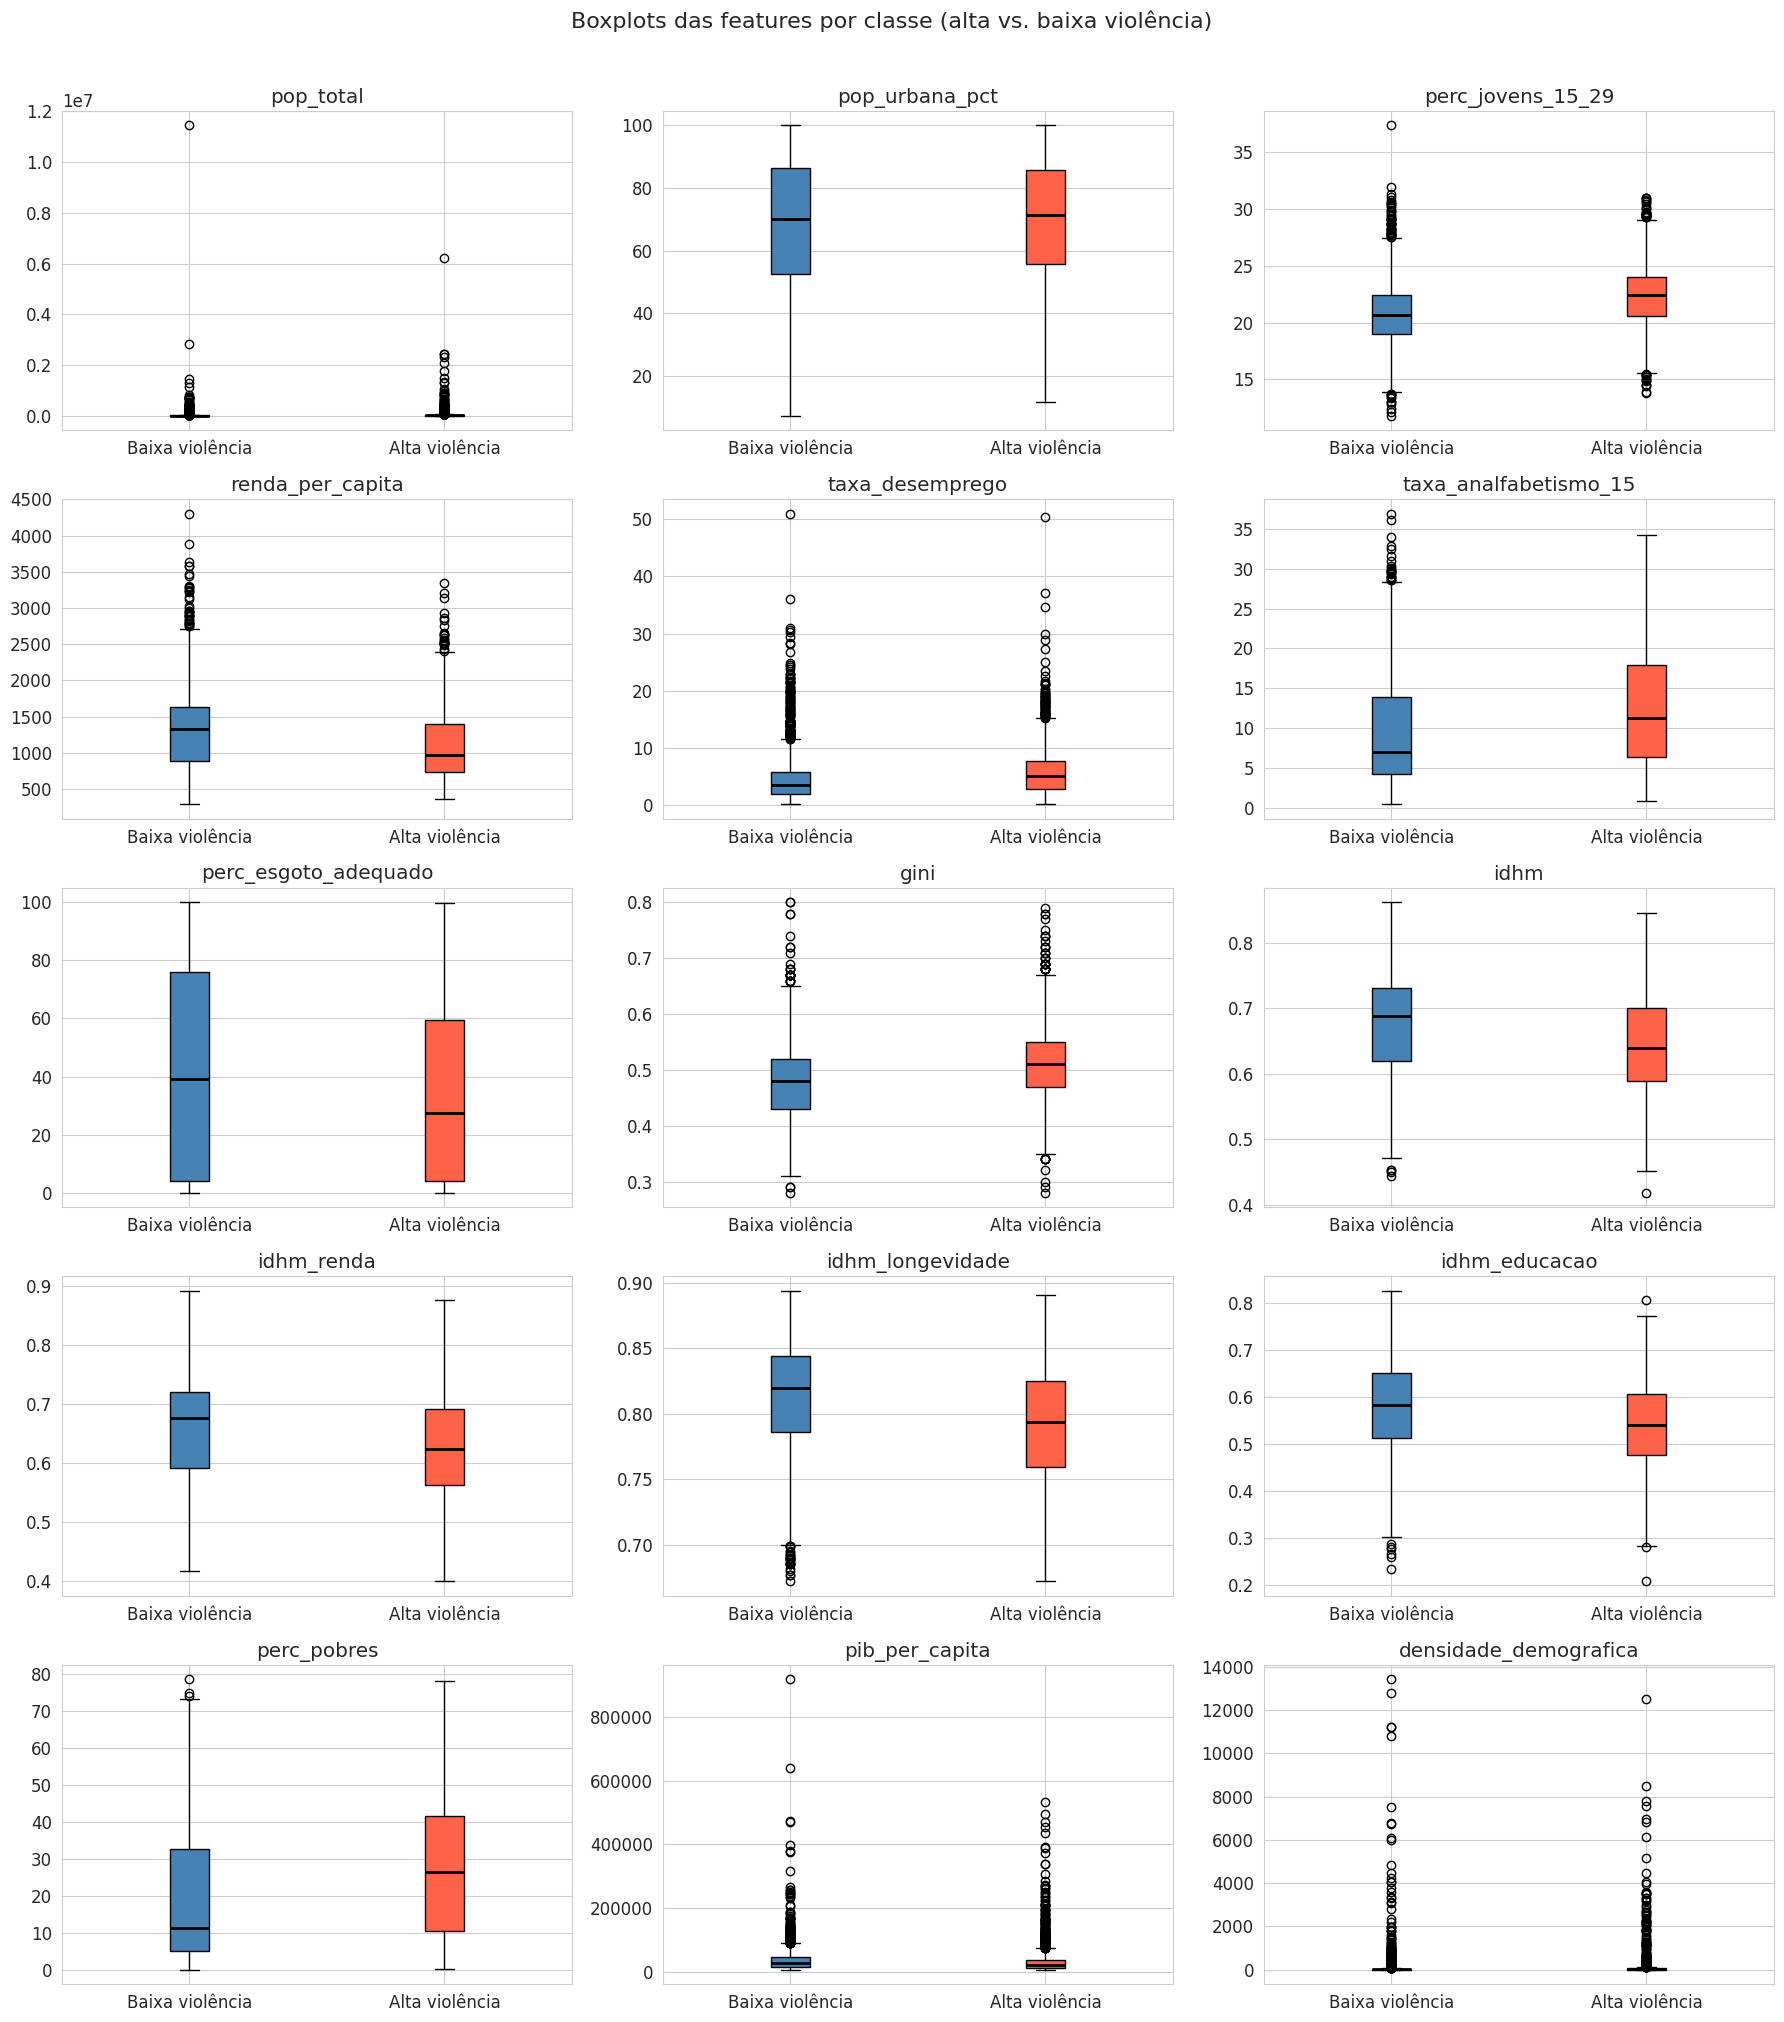

In [5]:
# Histogramas de todas as features
n_cols = 3
n_rows = (len(FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat)
    axes[i].set_ylabel('Freq.')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das features socioeconômicas', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_histogramas_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplots separados por classe
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

palette = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Baixa', 1: 'Alta'}

for i, feat in enumerate(FEATURES):
    data_baixa = df[df[TARGET] == 0][feat]
    data_alta  = df[df[TARGET] == 1][feat]
    bp = axes[i].boxplot(
        [data_baixa, data_alta],
        patch_artist=True,
        labels=['Baixa violência', 'Alta violência'],
        medianprops={'color': 'black', 'linewidth': 2},
    )
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(feat)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots das features por classe (alta vs. baixa violência)', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_boxplots_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Matriz de correlação

Correlação entre as features e com a variável alvo.

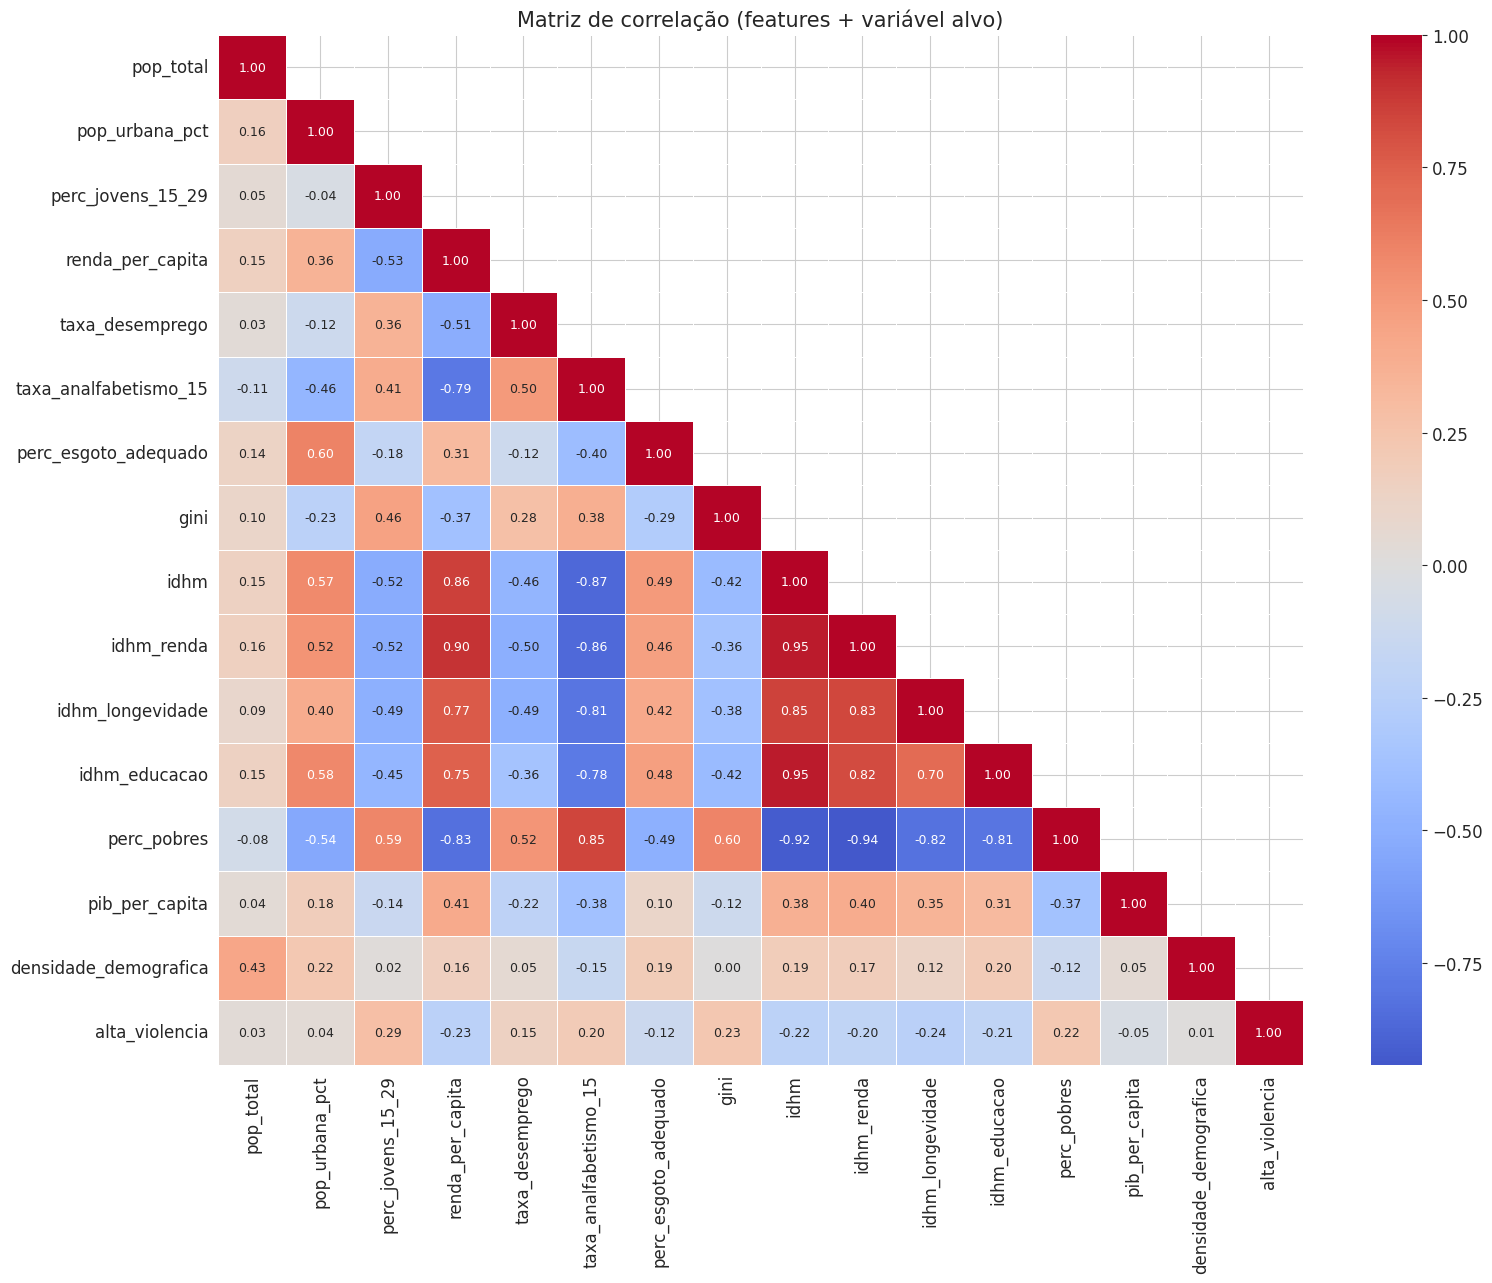

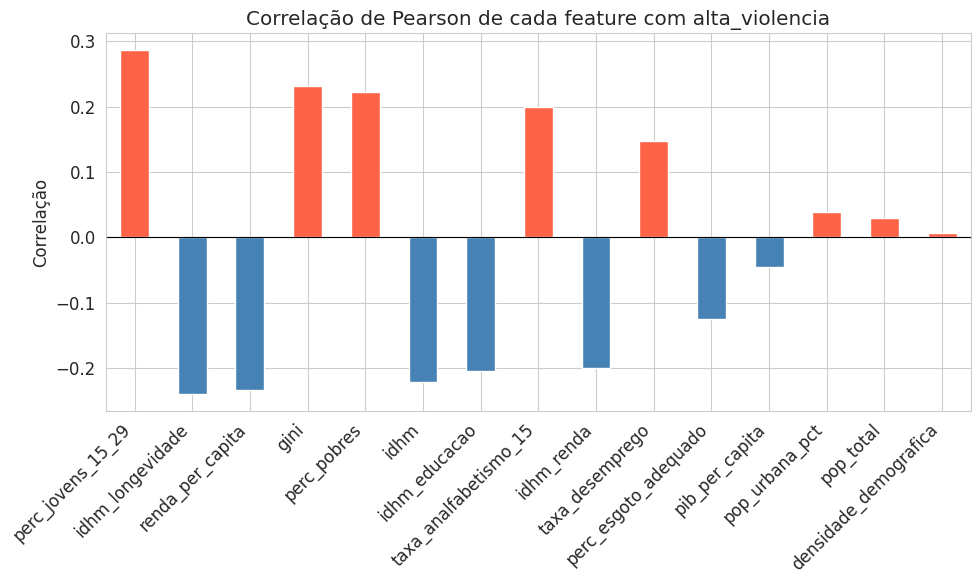

Top features por correlação absoluta com a variável alvo:
perc_jovens_15_29        0.285977
idhm_longevidade         0.239221
renda_per_capita         0.234244
gini                     0.231166
perc_pobres              0.222895
idhm                     0.221755
idhm_educacao            0.205089
taxa_analfabetismo_15    0.200044
idhm_renda               0.199636
taxa_desemprego          0.147576
perc_esgoto_adequado     0.124745
pib_per_capita           0.045257
pop_urbana_pct           0.039311
pop_total                0.030096
densidade_demografica    0.006499


In [6]:
# Heatmap de correlação entre features + alvo
corr = df[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 9},
)
ax.set_title('Matriz de correlação (features + variável alvo)', fontsize=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlação de cada feature com a variável alvo (ordenada)
corr_target = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_target]
corr_target.plot(kind='bar', color=colors, ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Correlação de Pearson de cada feature com alta_violencia')
ax.set_ylabel('Correlação')
ax.set_xticklabels(corr_target.index, rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_correlacao_com_alvo.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top features por correlação absoluta com a variável alvo:")
print(corr_target.abs().sort_values(ascending=False).to_string())

## 2.5 Análise bivariada

Scatter plots das features mais correlacionadas com a variável alvo.

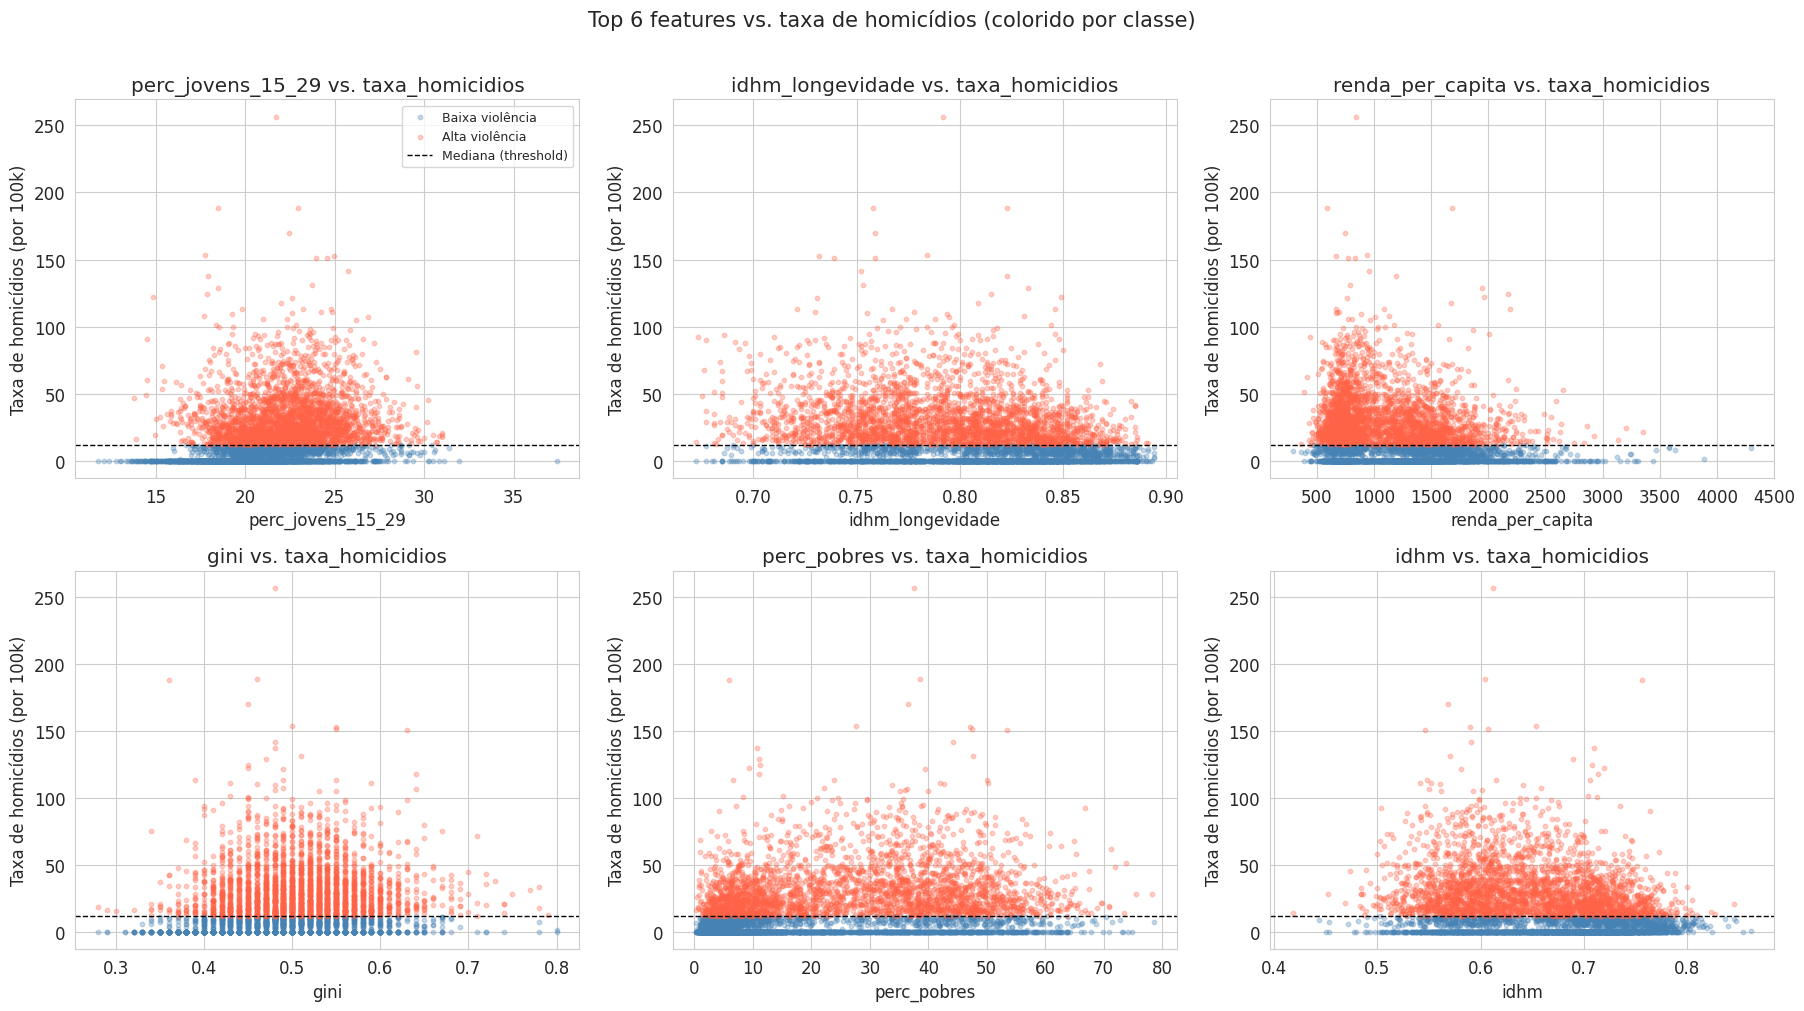

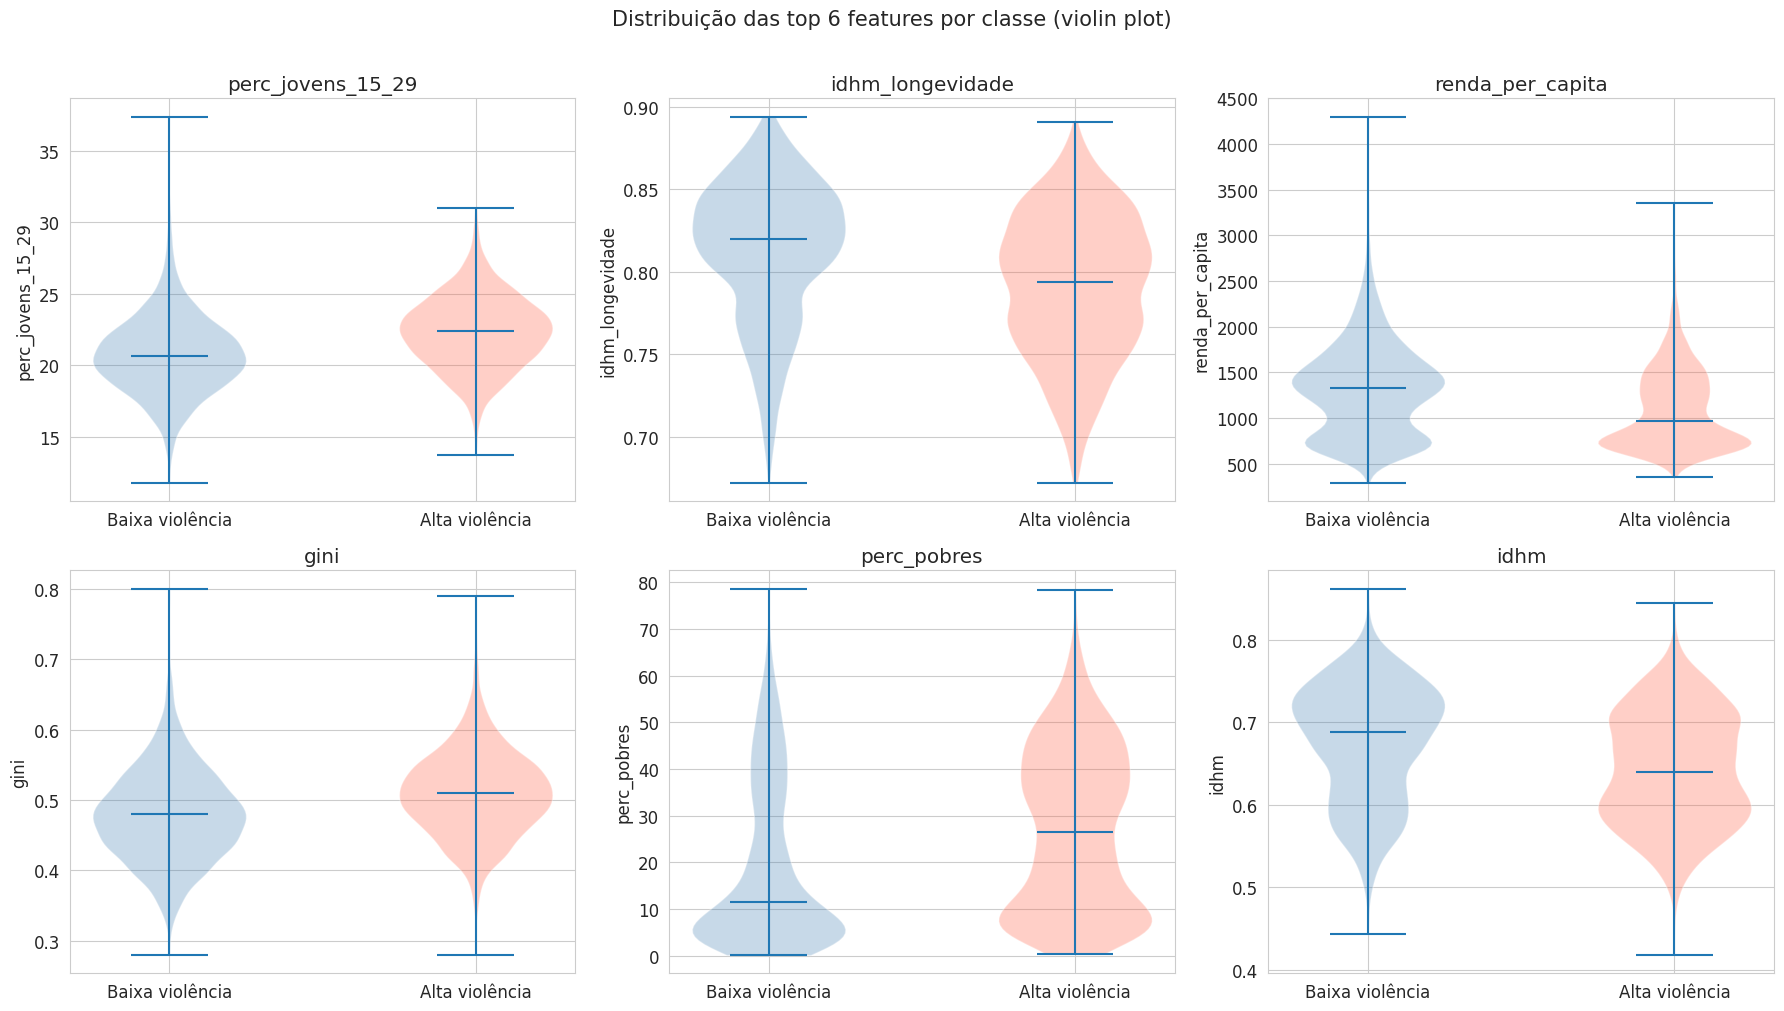

In [7]:
# Seleciona as 6 features mais correlacionadas com o alvo
top_features = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for classe, cor, label in [(0, 'steelblue', 'Baixa violência'), (1, 'tomato', 'Alta violência')]:
        subset = df[df[TARGET] == classe]
        axes[i].scatter(subset[feat], subset['taxa_homicidios'],
                        alpha=0.3, s=10, color=cor, label=label)
    axes[i].axhline(df['taxa_homicidios'].median(), color='black',
                    linestyle='--', linewidth=1, label='Mediana (threshold)')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Taxa de homicídios (por 100k)')
    axes[i].set_title(f'{feat} vs. taxa_homicidios')
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('Top 6 features vs. taxa de homicídios (colorido por classe)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_scatter_bivariado.png', dpi=150, bbox_inches='tight')
plt.show()

# Violin plots das top features por classe
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data = [df[df[TARGET] == 0][feat].values, df[df[TARGET] == 1][feat].values]
    vp = axes[i].violinplot(data, positions=[0, 1], showmedians=True)
    vp['bodies'][0].set_facecolor('steelblue')
    vp['bodies'][1].set_facecolor('tomato')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Baixa violência', 'Alta violência'])
    axes[i].set_title(feat)
    axes[i].set_ylabel(feat)

plt.suptitle('Distribuição das top 6 features por classe (violin plot)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_violin_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.6 Observações e insights

### Balanceamento do dataset
O dataset está perfeitamente balanceado (50%/50%) por construção — a variável alvo foi criada usando a mediana da taxa de homicídios como threshold. Isso é positivo pois elimina a necessidade de técnicas de re-balanceamento (SMOTE, class_weight, etc.).

### Distribuições das features
- **Pop. total** e **densidade demográfica** apresentam forte assimetria positiva (cauda longa à direita): a maioria dos municípios brasileiros é pequena, mas alguns centros urbanos são muito maiores.
- **IDHM** e sub-índices concentram-se em valores médios (0,6–0,75), com cauda esquerda mais longa — municípios muito pobres puxam a distribuição.
- **% pobres** e **taxa de analfabetismo** têm distribuição bimodal sugerindo divisão entre municípios desenvolvidos e subdesenvolvidos.

### Separabilidade entre classes
Pelos boxplots e violin plots, as features que melhor separam as classes são (confirmado pela correlação):
- **Features positivamente correlacionadas com alta violência:** `pop_urbana_pct`, `taxa_desemprego`, `gini`, `densidade_demografica`, `perc_jovens_15_29`
- **Features negativamente correlacionadas (protetoras):** `idhm`, `idhm_renda`, `idhm_educacao`, `idhm_longevidade`, `perc_esgoto_adequado`, `renda_per_capita`

### Multicolinearidade
A matriz de correlação revela alta colinearidade entre os sub-índices do IDHM (`idhm_renda`, `idhm_longevidade`, `idhm_educacao`) e o `idhm` geral, além de correlação elevada entre `renda_per_capita`, `perc_pobres` e `gini`. Isso é esperado dado que medem aspectos relacionados de desenvolvimento. Modelos sensíveis à colinearidade (como regressão logística) podem se beneficiar de seleção de features; árvores e SVM com RBF são menos afetados.

### Próximo passo
Com base na EDA, o pré-processamento (Notebook 03) aplicará **StandardScaler** a todas as features — necessário obrigatoriamente para SVM e recomendável para a rede neural. A árvore de decisão não requer normalização, mas será aplicada uniformemente para consistência experimental.